# 05 — DINOv2 Frozen: CV Convergence and Hold-out Results

DINOv2 ViT-B/14 frozen backbone + masked mean-pool over up to 8 SVIs per building + small MLP with three heads (`building_type`, `bouwjaar`, `num_floors`).
Trained with 5-fold StratifiedGroupKFold on the dev set; the best-fold checkpoint (by val macro-F1) is evaluated once on the held-out 2,018-building test set.

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
from _stage1_plot import (
    REPO, FIG_DIR, TABLE_DIR, REPORTS_DIR,
    setup_mpl, save_fig, save_table, confusion_heatmap,
    compute_locked_limits, provenance_table,
    TYPE_LABELS, CITY_LABELS, TYPE_PALETTE, CITY_PALETTE,
)

setup_mpl()
AXIS_LIMITS = compute_locked_limits()

from sklearn.metrics import f1_score

DINO_DIR = REPORTS_DIR / 'dinov2_frozen'
fold_history   = [DINO_DIR / f'pooled_fold{f}_history.json' for f in range(5)]
fold_val_preds = [DINO_DIR / f'pooled_fold{f}_val_preds.parquet' for f in range(5)]
agg_path       = DINO_DIR / 'pooled_aggregate_metrics.json'
ho_metrics_path = DINO_DIR / 'holdout_metrics.json'
ho_preds_path   = DINO_DIR / 'holdout_preds.parquet'

history = []
history_summaries = []
for f, p in enumerate(fold_history):
    d = json.loads(p.read_text())
    for ep in d['history']:
        history.append({'fold': f, **ep})
    history_summaries.append({'fold': f,
                              'best_epoch': d['best_epoch'],
                              'best_val_macro_f1': d['best_val_macro_f1']})
history = pd.DataFrame(history)
history_summaries = pd.DataFrame(history_summaries)

# Per-fold metrics computed from val_preds (folds 1-4 lack a metrics.json)
def _compute_fold_metrics(parquet: Path) -> dict:
    df = pd.read_parquet(parquet)
    type_acc   = float((df['pred_type'] == df['true_type']).mean())
    macro_f1   = float(f1_score(df['true_type'], df['pred_type'],
                                labels=TYPE_LABELS, average='macro', zero_division=0))
    year_mae   = float((df['pred_year']   - df['true_bouwjaar']).abs().mean())
    floors_mae = float((df['pred_floors'] - df['true_num_floors']).abs().mean())
    return dict(type_acc=type_acc, type_macro_f1=macro_f1,
                year_mae=year_mae, floors_mae=floors_mae, n=len(df))

fold_metric_dicts = [_compute_fold_metrics(p) for p in fold_val_preds]
agg_metrics = json.loads(agg_path.read_text())
ho_metrics  = json.loads(ho_metrics_path.read_text())
ho_preds    = pd.read_parquet(ho_preds_path)

prov_df = provenance_table(fold_history + fold_val_preds + [agg_path, ho_metrics_path, ho_preds_path])
print('AXIS_LIMITS:', AXIS_LIMITS)
prov_df

AXIS_LIMITS: {'year_scatter': (1850, 2030), 'year_mae_bar': (0.0, 53), 'floors_mae_bar': (0.0, 0.9), 'type_acc_bar': (0.0, 1.0)}


,file,size_kb,mtime
0,reports\stage1\dinov2_frozen\pooled_fold0_hist...,17.4,2026-05-22 00:46
1,reports\stage1\dinov2_frozen\pooled_fold1_hist...,10.7,2026-05-22 10:04
2,reports\stage1\dinov2_frozen\pooled_fold2_hist...,18.6,2026-05-22 12:34
3,reports\stage1\dinov2_frozen\pooled_fold3_hist...,18.6,2026-05-22 15:03
4,reports\stage1\dinov2_frozen\pooled_fold4_hist...,14.3,2026-05-22 17:00
5,reports\stage1\dinov2_frozen\pooled_fold0_val_...,43.9,2026-05-22 00:46
6,reports\stage1\dinov2_frozen\pooled_fold1_val_...,43.9,2026-05-22 10:04
7,reports\stage1\dinov2_frozen\pooled_fold2_val_...,44.1,2026-05-22 12:34
8,reports\stage1\dinov2_frozen\pooled_fold3_val_...,44.0,2026-05-22 15:03
9,reports\stage1\dinov2_frozen\pooled_fold4_val_...,44.0,2026-05-22 17:00


## 1. 5-fold CV: training & model selection

[fig] reports\figures\stage1\dinov2\F1_cv_val_curves.png  +  F1_cv_val_curves.pdf


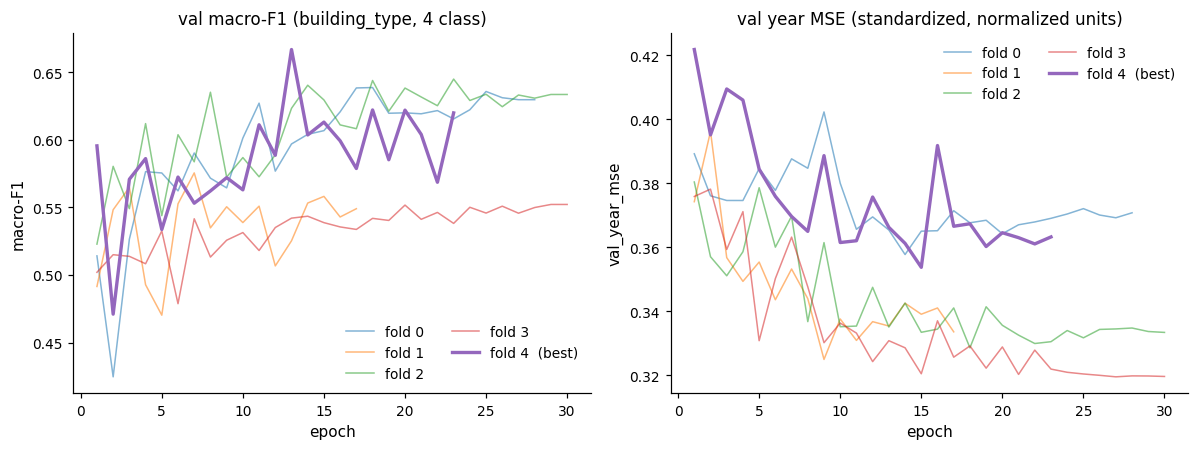

In [2]:
best_fold_idx = int(history_summaries['best_val_macro_f1'].idxmax())

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True)

for f, sub in history.groupby('fold'):
    is_best = (f == best_fold_idx)
    lw = 2.2 if is_best else 1.0
    alpha = 1.0 if is_best else 0.55
    label = f'fold {f}' + ('  (best)' if is_best else '')
    axes[0].plot(sub['epoch'], sub['val_type_macro_f1'], lw=lw, alpha=alpha, label=label)
    axes[1].plot(sub['epoch'], sub['val_year_mse'], lw=lw, alpha=alpha, label=label)

axes[0].set_title('val macro-F1 (building_type, 4 class)')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('macro-F1')
axes[0].legend(frameon=False, ncol=2)

axes[1].set_title('val year MSE (standardized, normalized units)')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('val_year_mse')
axes[1].legend(frameon=False, ncol=2)

fig.tight_layout()
save_fig(fig, 'F1_cv_val_curves', 'dinov2')
plt.show()

### Loss curves (training diagnostics)

Total loss = class-weighted CE (type) + MSE (standardized year) + MSE (standardized floors), equal weights (`src/stage1/train.py`). Dashed = train, solid = val.

Checkpoint selection uses **val macro-F1**, not val loss: with 88% AB the total loss is dominated by the majority class and the regression terms, so its minimum need not coincide with the best 4-class operating point. Loss curves are kept as a sanity diagnostic (no divergence / no NaN).

[fig] reports\figures\stage1\dinov2\F4_dinov2_loss_components.png  +  F4_dinov2_loss_components.pdf


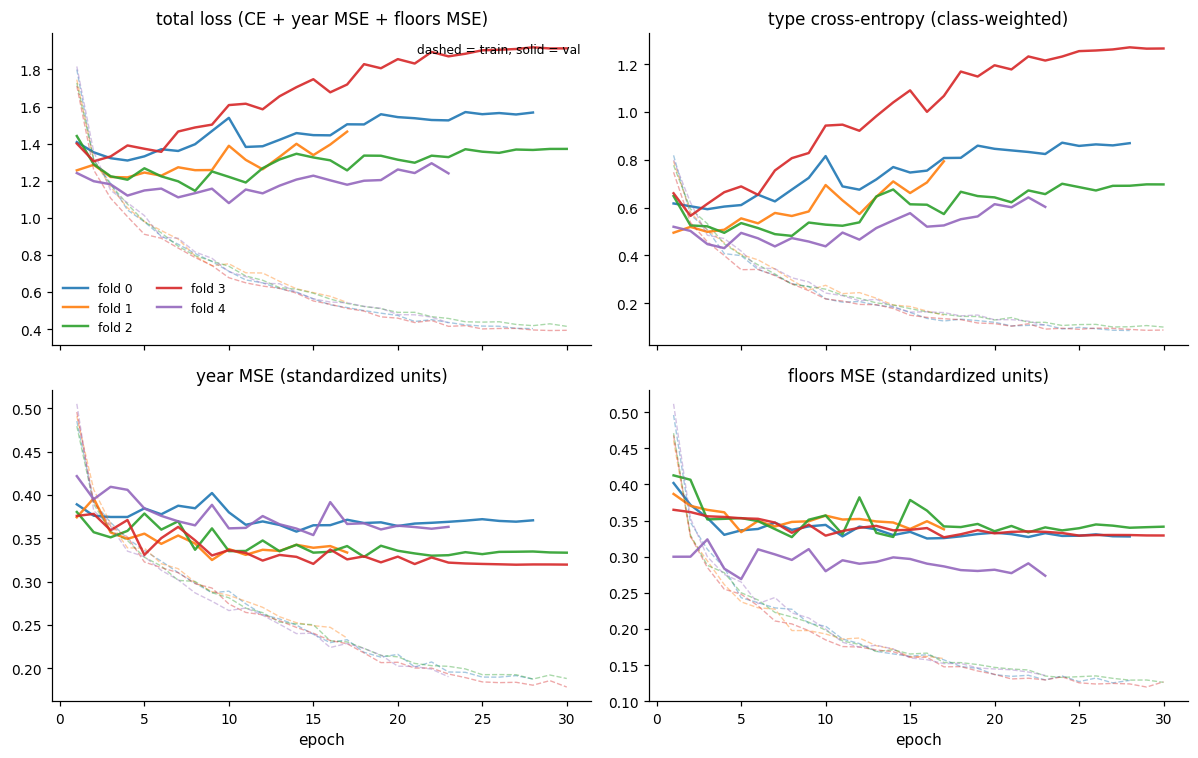

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
panels = [('loss',       'total loss (CE + year MSE + floors MSE)'),
          ('ce',         'type cross-entropy (class-weighted)'),
          ('year_mse',   'year MSE (standardized units)'),
          ('floors_mse', 'floors MSE (standardized units)')]
fold_colors = dict(zip(range(5), plt.rcParams['axes.prop_cycle'].by_key()['color']))
for ax, (key, title) in zip(axes.flat, panels):
    for f, sub in history.groupby('fold'):
        ax.plot(sub['epoch'], sub[f'train_{key}'], lw=0.9, alpha=0.4, linestyle='--', color=fold_colors[f])
        ax.plot(sub['epoch'], sub[f'val_{key}'],   lw=1.6, alpha=0.9, color=fold_colors[f], label=f'fold {f}')
    ax.set_title(title)
axes[1, 0].set_xlabel('epoch'); axes[1, 1].set_xlabel('epoch')
axes[0, 0].legend(frameon=False, ncol=2, fontsize=8)
axes[0, 0].text(0.98, 0.97, 'dashed = train, solid = val',
                transform=axes[0, 0].transAxes, ha='right', va='top', fontsize=8)
fig.tight_layout()
save_fig(fig, 'F4_dinov2_loss_components', 'dinov2')
plt.show()

In [4]:
rows = []
for f, m in enumerate(fold_metric_dicts):
    rows.append({
        'fold': f,
        'n_val':       m['n'],
        'type_acc':    m['type_acc'],
        'macro_f1':    m['type_macro_f1'],
        'year_mae':    m['year_mae'],
        'floors_mae':  m['floors_mae'],
    })
cv_df = pd.DataFrame(rows)
mean_row = {'fold': 'mean', 'n_val': cv_df['n_val'].sum()}
std_row  = {'fold': 'std',  'n_val': None}
for c in ['type_acc', 'macro_f1', 'year_mae', 'floors_mae']:
    mean_row[c] = cv_df[c].mean()
    std_row[c]  = cv_df[c].std(ddof=1)
cv_out = pd.concat([cv_df, pd.DataFrame([mean_row, std_row])], ignore_index=True)
save_table(cv_out, 'T1_dinov2_cv_per_fold')
print(f'best fold by val_macro_f1: fold {best_fold_idx} '
      f'(best_val_macro_f1={history_summaries.loc[best_fold_idx, "best_val_macro_f1"]:.4f})')
print(f'best ckpt: models/stage1/pooled_dinov2_frozen_fold{best_fold_idx}.pt')
cv_out

[tbl] reports\tables\stage1\T1_dinov2_cv_per_fold.csv  +  T1_dinov2_cv_per_fold.md
best fold by val_macro_f1: fold 4 (best_val_macro_f1=0.6667)
best ckpt: models/stage1/pooled_dinov2_frozen_fold4.pt


,fold,n_val,type_acc,macro_f1,year_mae,floors_mae
0,0,1614.0,0.907063,0.638629,9.739046,0.353344
1,1,1613.0,0.894606,0.575481,10.417759,0.361234
2,2,1614.0,0.910781,0.644877,9.309341,0.362047
3,3,1614.0,0.921314,0.552149,9.540280,0.343649
4,4,1613.0,0.916305,0.666737,9.710894,0.362142
5,mean,8068.0,0.910014,0.615574,9.743464,0.356483
6,std,NaN,0.010173,0.049087,0.413975,0.008064


## 2. Hold-out test results

In [5]:
assert len(ho_preds) == 2018, f'expected n=2018, got {len(ho_preds)}'
ci = ho_metrics['bootstrap_95ci']

headline = pd.DataFrame([{
    'n_eval':              ho_metrics['n_eval'],
    'type_acc':            ho_metrics['type_acc'],
    'type_acc_lo':         ci['type_acc']['lo'],
    'type_acc_hi':         ci['type_acc']['hi'],
    'macro_f1':            ho_metrics['type_macro_f1'],
    'macro_f1_lo':         ci['type_macro_f1']['lo'],
    'macro_f1_hi':         ci['type_macro_f1']['hi'],
    'year_mae':            ho_metrics['year_mae'],
    'year_mae_lo':         ci['year_mae']['lo'],
    'year_mae_hi':         ci['year_mae']['hi'],
    'year_within_10y_pct': ho_metrics['year_within_10y_pct'],
    'floors_mae':          ho_metrics['floors_mae'],
    'floors_mae_lo':       ci['floors_mae']['lo'],
    'floors_mae_hi':       ci['floors_mae']['hi'],
    'floors_exact_pct':    ho_metrics['floors_exact_pct'],
}])
save_table(headline, 'T2_dinov2_holdout_headline')
headline.T

[tbl] reports\tables\stage1\T2_dinov2_holdout_headline.csv  +  T2_dinov2_holdout_headline.md


,0
n_eval,2018.0000
type_acc,0.9014
type_acc_lo,0.8890
type_acc_hi,0.9143
macro_f1,0.5197
macro_f1_lo,0.4732
macro_f1_hi,0.5611
year_mae,9.4500
year_mae_lo,8.8266
year_mae_hi,10.0557


[fig] reports\figures\stage1\dinov2\F2_dinov2_holdout_type_year.png  +  F2_dinov2_holdout_type_year.pdf


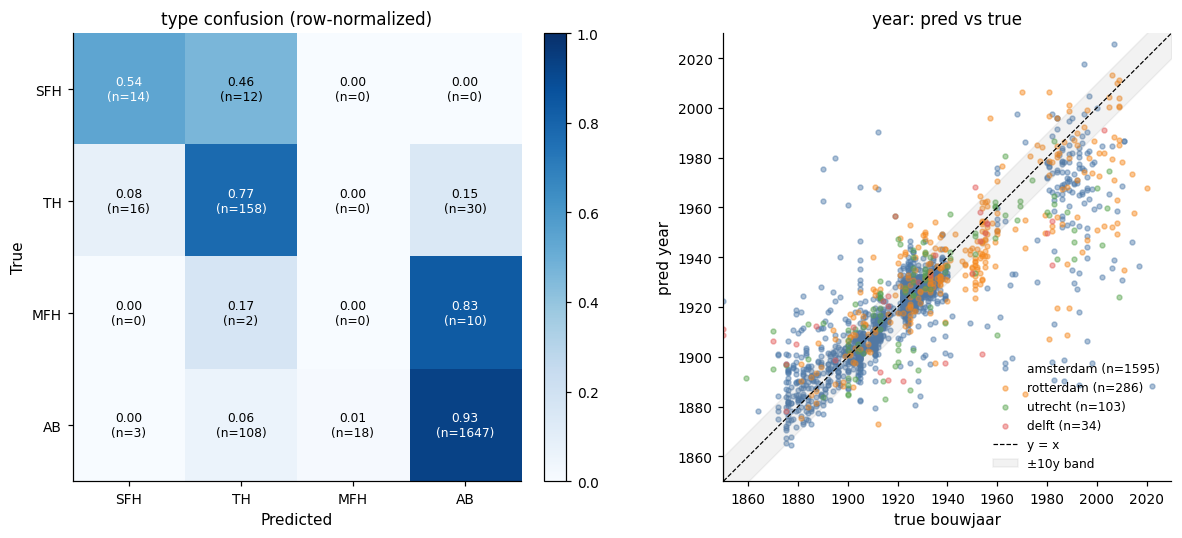

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = np.asarray(ho_metrics['type_confusion_matrix']['matrix'])
labels = ho_metrics['type_confusion_matrix']['labels']
confusion_heatmap(cm, labels, axes[0], title='type confusion (row-normalized)')

ax = axes[1]
for city in CITY_LABELS:
    sub = ho_preds[ho_preds['city'] == city]
    ax.scatter(sub['true_bouwjaar'], sub['pred_year'],
               s=10, alpha=0.45, color=CITY_PALETTE[city], label=f'{city} (n={len(sub)})')
lo, hi = AXIS_LIMITS['year_scatter']
ax.plot([lo, hi], [lo, hi], color='black', lw=0.8, linestyle='--', label='y = x')
ax.fill_between([lo, hi], [lo - 10, hi - 10], [lo + 10, hi + 10],
                color='gray', alpha=0.10, label='±10y band')
ax.set_xlim(*AXIS_LIMITS['year_scatter']); ax.set_ylim(*AXIS_LIMITS['year_scatter'])
ax.set_xlabel('true bouwjaar'); ax.set_ylabel('pred year')
ax.set_title('year: pred vs true')
ax.legend(frameon=False, fontsize=8, loc='lower right')
ax.set_aspect('equal', adjustable='box')

fig.tight_layout()
save_fig(fig, 'F2_dinov2_holdout_type_year', 'dinov2')
plt.show()

[fig] reports\figures\stage1\dinov2\F3_dinov2_per_class_per_city.png  +  F3_dinov2_per_class_per_city.pdf


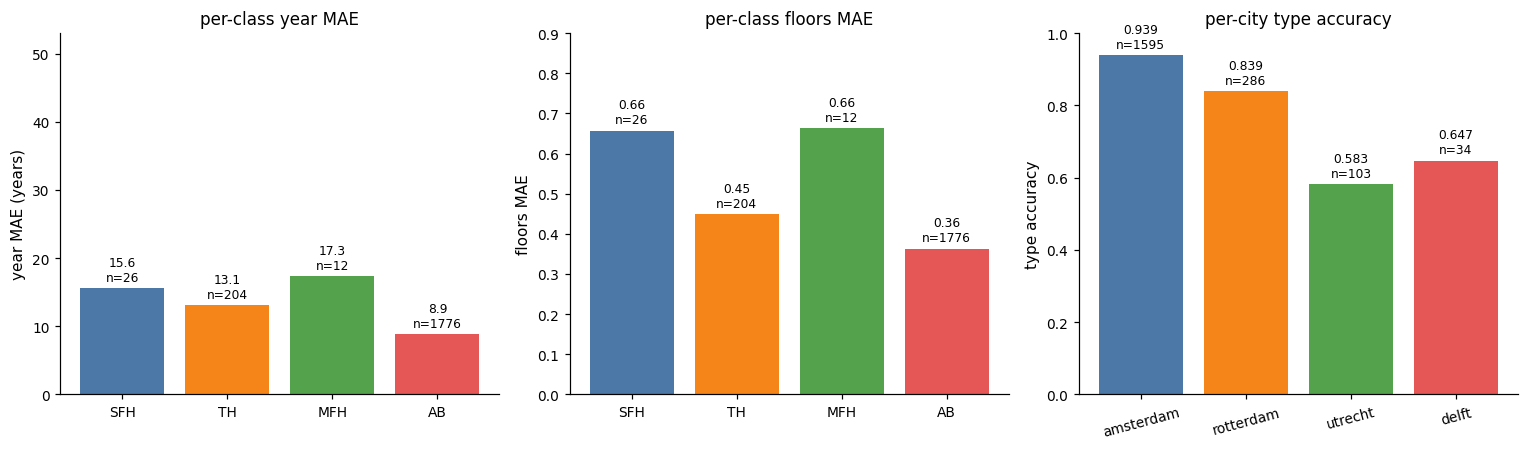

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

# Left: per-class year MAE
pc = ho_metrics['per_class_year_floors']
y_vals = [pc[t]['year_mae'] for t in TYPE_LABELS]
f_vals = [pc[t]['floors_mae'] for t in TYPE_LABELS]
n_per_class = [pc[t]['n'] for t in TYPE_LABELS]
axes[0].bar(TYPE_LABELS, y_vals, color=[TYPE_PALETTE[t] for t in TYPE_LABELS])
axes[0].set_ylim(*AXIS_LIMITS['year_mae_bar'])
axes[0].set_ylabel('year MAE (years)')
axes[0].set_title('per-class year MAE')
for i, (v, n) in enumerate(zip(y_vals, n_per_class)):
    axes[0].text(i, v + AXIS_LIMITS['year_mae_bar'][1]*0.02, f'{v:.1f}\nn={n}', ha='center', fontsize=8)

# Middle: per-class floors MAE
axes[1].bar(TYPE_LABELS, f_vals, color=[TYPE_PALETTE[t] for t in TYPE_LABELS])
axes[1].set_ylim(*AXIS_LIMITS['floors_mae_bar'])
axes[1].set_ylabel('floors MAE')
axes[1].set_title('per-class floors MAE')
for i, (v, n) in enumerate(zip(f_vals, n_per_class)):
    axes[1].text(i, v + AXIS_LIMITS['floors_mae_bar'][1]*0.02, f'{v:.2f}\nn={n}', ha='center', fontsize=8)

# Right: per-city type accuracy
per_city = ho_metrics['per_city']
city_acc = [per_city[c]['type_acc'] for c in CITY_LABELS]
city_n   = [per_city[c]['n'] for c in CITY_LABELS]
axes[2].bar(CITY_LABELS, city_acc, color=[CITY_PALETTE[c] for c in CITY_LABELS])
axes[2].set_ylim(*AXIS_LIMITS['type_acc_bar'])
axes[2].set_ylabel('type accuracy')
axes[2].set_title('per-city type accuracy')
for i, (v, n) in enumerate(zip(city_acc, city_n)):
    axes[2].text(i, v + 0.02, f'{v:.3f}\nn={n}', ha='center', fontsize=8)
axes[2].tick_params(axis='x', rotation=15)

fig.tight_layout()
save_fig(fig, 'F3_dinov2_per_class_per_city', 'dinov2')
plt.show()